# Logistic Regression: Training and Evaluation

This notebook trains a Logistic Regression model on preprocessed heart disease data and reports:
- Accuracy, Precision, Recall, F1-score, AUC-ROC
- Confusion Matrix and ROC Curve
- Feature coefficient importance (bar chart)

In [2]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

# Load preprocessed train/test data
train_df = pd.read_csv("heart_train_preprocessed.csv")
test_df = pd.read_csv("heart_test_preprocessed.csv")

X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (241, 30)
Test shape: (61, 30)


In [3]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions and probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("AUC-ROC  :", round(auc_roc, 4))

Accuracy : 0.8361
Precision: 0.8485
Recall   : 0.8485
F1-score : 0.8485
AUC-ROC  : 0.9048


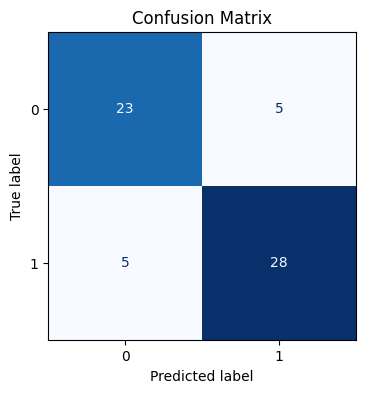

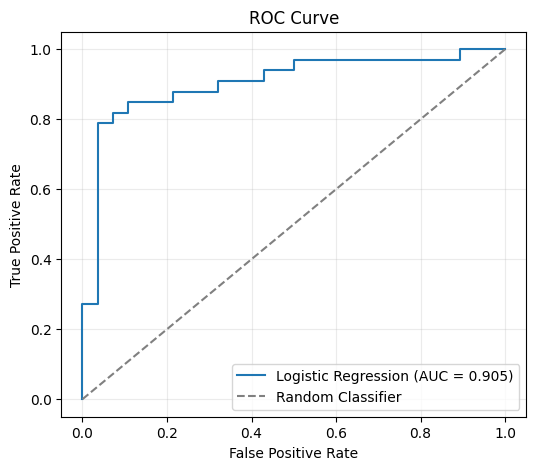

In [4]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_roc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

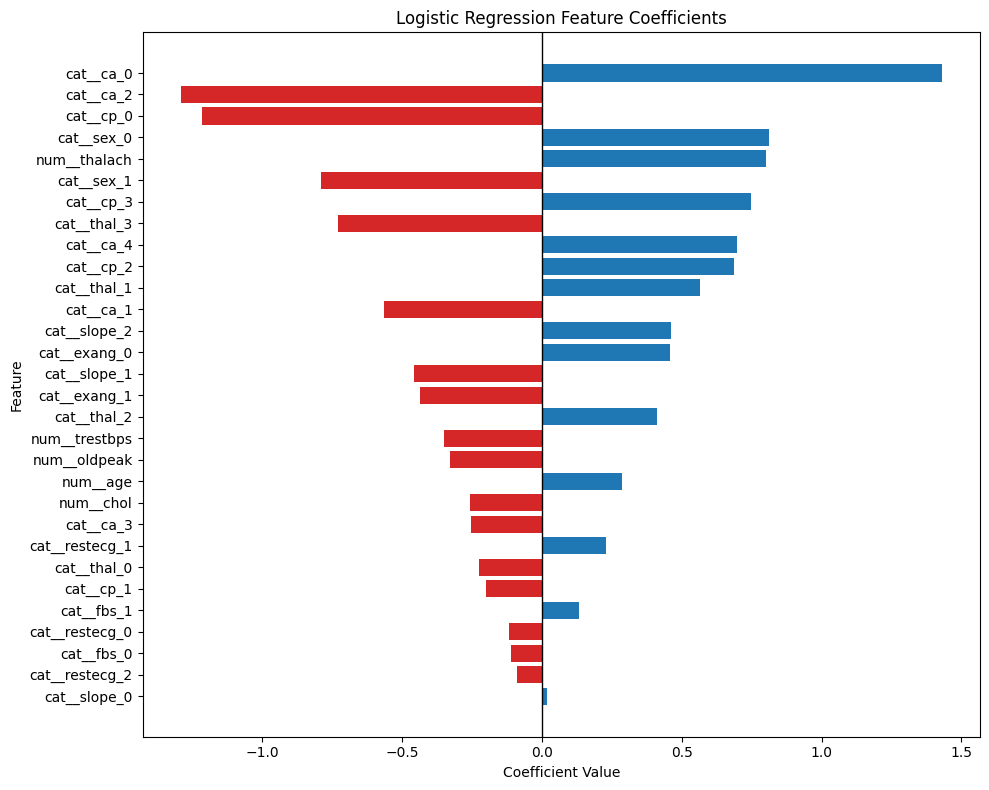

Top 10 important features (absolute coefficient):


cat__ca_0       1.430413
cat__ca_2       1.291609
cat__cp_0       1.215932
cat__sex_0      0.813260
num__thalach    0.802284
cat__sex_1      0.790919
cat__cp_3       0.749456
cat__thal_3     0.730525
cat__ca_4       0.698197
cat__cp_2       0.686816
dtype: float64

In [5]:
# Feature coefficients (importance)
coef_series = pd.Series(model.coef_[0], index=X_train.columns)
coef_sorted = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
plt.barh(coef_sorted.index, coef_sorted.values, color=["#1f77b4" if v > 0 else "#d62728" for v in coef_sorted.values])
plt.axvline(x=0, color="black", linewidth=1)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Show top 10 features by absolute magnitude
print("Top 10 important features (absolute coefficient):")
display(coef_series.abs().sort_values(ascending=False).head(10))